In [ ]:
# -*- coding: utf-8 -*-
"""VK RecSys Challenge LSVD - оптимизированная версия с правильными локальными путями"""

import subprocess
import sys


required_packages = [
    'faiss-cpu',
    'polars',
    'torch',
    'huggingface_hub',
    'tqdm',
    'numpy'
]
for package in required_packages:
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        print(f"Устанавливаю {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import gc
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import faiss
from tqdm import tqdm
import random
from collections import defaultdict
from huggingface_hub import hf_hub_download

# ------------------------------
# 0. Конфигурация
# ------------------------------
SUBSAMPLE = 'up0.001_ip0.001' # название подвыборки (0.1% пользователей и клипов)
LOCAL_DIR = 'VK-LSVD_subsample' # папка для сохранения данных

REPO_ID = 'deepvk/VK-LSVD'
REPO_TYPE = 'dataset'

USERS_META_PATH = 'metadata/users_metadata.parquet'
ITEMS_META_PATH = 'metadata/items_metadata.parquet'

TRAIN_WEEK_PATTERN = f'subsamples/{SUBSAMPLE}/train/week_{{:02d}}.parquet'
VAL_WEEK = f'subsamples/{SUBSAMPLE}/validation/week_25.parquet'
TEST_WEEK = f'subsamples/{SUBSAMPLE}/test/week_26.parquet'

# Для примера используем только неделю 00 (можно расширить)
TRAIN_WEEKS = [0]  # добавить другие недели при необходимости

EMBED_DIM = 256 # размерность эмбеддингов
BATCH_SIZE = 1024
NEG_RATIO = 5 # на каждый положительный пример генерируем 5 отрицательных
EPOCHS = 5
LEARNING_RATE = 0.001
TOP_K_CANDIDATES = 500 # сколько кандидатов искать через FAISS для каждого клипа
MAX_USER_USES = 100 # ограничение на количество рекомендаций одного пользователя

RELEVANT_COLUMNS = ['like', 'share', 'bookmark']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


Устанавливаю faiss-cpu...


* SUBSAMPLE = 'up0.001_ip0.001' означает, что мы используем подвыборку размером 0.1% от полного датасета — это сделано для того, чтобы код работал быстро и не требовал больших ресурсов.


In [ ]:
# ------------------------------
# 1. Скачиваем все необходимые файлы и сохраняем локальные пути
# ------------------------------
print("Скачивание файлов...")

# Метаданные
users_meta_local = hf_hub_download( # metadata/users_metadata.parquet
    repo_id=REPO_ID, repo_type=REPO_TYPE, filename=USERS_META_PATH, local_dir=LOCAL_DIR
)
items_meta_local = hf_hub_download( # metadata/items_metadata.parquet
    repo_id=REPO_ID, repo_type=REPO_TYPE, filename=ITEMS_META_PATH, local_dir=LOCAL_DIR
)

# Тренировочные файлы
train_files_local = [] # скачиваем week_00.parquet (из train)
for week in TRAIN_WEEKS:
    fname = TRAIN_WEEK_PATTERN.format(week)
    local_path = hf_hub_download(repo_id=REPO_ID, repo_type=REPO_TYPE, filename=fname, local_dir=LOCAL_DIR)
    train_files_local.append(local_path)

# Валидация
val_file_local = hf_hub_download( # week_25.parquet (validation)
    repo_id=REPO_ID, repo_type=REPO_TYPE, filename=VAL_WEEK, local_dir=LOCAL_DIR
)

# Тест
test_file_local = hf_hub_download( # week_26.parquet (test)
    repo_id=REPO_ID, repo_type=REPO_TYPE, filename=TEST_WEEK, local_dir=LOCAL_DIR
)

Скачивание файлов...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


metadata/users_metadata.parquet:   0%|          | 0.00/72.5M [00:00<?, ?B/s]

metadata/items_metadata.parquet:   0%|          | 0.00/156M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/train/week_00(…):   0%|          | 0.00/3.02M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/validation/we(…):   0%|          | 0.00/2.62M [00:00<?, ?B/s]

subsamples/up0.001_ip0.001/test/week_26.(…):   0%|          | 0.00/2.00M [00:00<?, ?B/s]

In [ ]:
# ------------------------------
# 2. Сбор уникальных ID из всех взаимодействий Используется ленивое чтение Polars (scan_parquet), чтобы получить уникальные значения колонки user_id или item_id без загрузки всего файла в память.
#Собираем все уникальные ID из тренировочных, валидационных и тестовых файлов. Это понадобится, чтобы потом загрузить только нужные строки из метаданных.
# ------------------------------
def get_unique_ids_from_file(file_path: str, id_column: str) -> set:
    lazy = pl.scan_parquet(file_path)
    return set(lazy.select(id_column).unique().collect()[id_column].to_list())

print("Собираем уникальные ID пользователей и клипов...")
all_user_ids = set()
all_item_ids = set()

for f in train_files_local:
    print(f"  Обработка {f}")
    all_user_ids.update(get_unique_ids_from_file(f, 'user_id'))
    all_item_ids.update(get_unique_ids_from_file(f, 'item_id'))

print(f"  Обработка {val_file_local}")
all_user_ids.update(get_unique_ids_from_file(val_file_local, 'user_id'))
all_item_ids.update(get_unique_ids_from_file(val_file_local, 'item_id'))

print(f"  Обработка {test_file_local}")
all_user_ids.update(get_unique_ids_from_file(test_file_local, 'user_id'))
all_item_ids.update(get_unique_ids_from_file(test_file_local, 'item_id'))

print(f"Уникальных пользователей: {len(all_user_ids)}")
print(f"Уникальных клипов: {len(all_item_ids)}")


Собираем уникальные ID пользователей и клипов...
  Обработка VK-LSVD_subsample/subsamples/up0.001_ip0.001/train/week_00.parquet
  Обработка VK-LSVD_subsample/subsamples/up0.001_ip0.001/validation/week_25.parquet
  Обработка VK-LSVD_subsample/subsamples/up0.001_ip0.001/test/week_26.parquet
Уникальных пользователей: 9998
Уникальных клипов: 11106


In [ ]:
# ------------------------------
# 3. Загрузка отфильтрованных метаданных
# ------------------------------
print("Загрузка метаданных пользователей (только нужные)...")
users_meta_all = pl.scan_parquet(users_meta_local)
users_meta_filtered = users_meta_all.filter(pl.col('user_id').is_in(all_user_ids)).collect()
print(f"Загружено {len(users_meta_filtered)} пользователей")

print("Загрузка метаданных клипов (только нужные)...")
items_meta_all = pl.scan_parquet(items_meta_local)
items_meta_filtered = items_meta_all.filter(pl.col('item_id').is_in(all_item_ids)).collect()
print(f"Загружено {len(items_meta_filtered)} клипов")

# Матрицы признаков
user_feat_df = users_meta_filtered.drop('user_id')
item_feat_df = items_meta_filtered.drop('item_id')
user_feat_matrix = user_feat_df.to_numpy().astype(np.float32)
item_feat_matrix = item_feat_df.to_numpy().astype(np.float32)

# Отображения
user_ids = users_meta_filtered['user_id'].to_list()
item_ids = items_meta_filtered['item_id'].to_list()
user2idx = {uid: i for i, uid in enumerate(user_ids)}
item2idx = {iid: i for i, iid in enumerate(item_ids)}
idx2user = {i: uid for uid, i in user2idx.items()}
idx2item = {i: iid for iid, i in item2idx.items()}
user_set = set(user_ids)
item_set = set(item_ids)

# Очистка
del users_meta_all, items_meta_all, users_meta_filtered, items_meta_filtered
gc.collect()


Загрузка метаданных пользователей (только нужные)...
Загружено 9998 пользователей
Загрузка метаданных клипов (только нужные)...
Загружено 11106 клипов


107

создаются словари user2idx и item2idx для преобразования ID в индексы, и обратные словари idx2user и idx2item.

In [ ]:
# ------------------------------
# 4. Загрузка взаимодействий (только нужные строки)
#Загружаем только те строки, где оба ID присутствуют в наших множествах. Параметр engine='streaming' позволяет обрабатывать данные без полной загрузки в память (по частям). Это важно для больших файлов, даже для подвыборки.
#Из тестового файла извлекаем список уникальных item_id – именно для них нужно делать предсказания.
# ------------------------------
def load_interactions_filtered(file_path: str, user_set: set, item_set: set) -> pl.DataFrame:
    lazy = pl.scan_parquet(file_path)
    filtered = lazy.filter(
        pl.col('user_id').is_in(user_set) & pl.col('item_id').is_in(item_set)
    )
    return filtered.collect(engine='streaming')

print("Загрузка обучающих взаимодействий...")
# Если несколько тренировочных файлов, объединяем их
train_dfs = []
for f in train_files_local:
    train_dfs.append(load_interactions_filtered(f, user_set, item_set))
train_interactions = pl.concat(train_dfs) if len(train_dfs) > 1 else train_dfs[0]
print(f"Загружено обучающих взаимодействий: {len(train_interactions)}")

print("Загрузка валидационных взаимодействий...")
val_interactions = load_interactions_filtered(val_file_local, user_set, item_set)
print(f"Загружено валидационных взаимодействий: {len(val_interactions)}")

print("Загрузка тестовых взаимодействий...")
test_interactions = load_interactions_filtered(test_file_local, user_set, item_set)
test_item_ids = test_interactions['item_id'].unique().to_list()
print(f"Уникальных тестовых клипов: {len(test_item_ids)}")

Загрузка обучающих взаимодействий...
Загружено обучающих взаимодействий: 625523
Загрузка валидационных взаимодействий...
Загружено валидационных взаимодействий: 519839
Загрузка тестовых взаимодействий...
Уникальных тестовых клипов: 8719


Следующий шаг — загрузка самих взаимодействий. Функция load_interactions_filtered похожа на предыдущую, но здесь важно, что мы фильтруем строки, оставляя только те, у которых user_id и item_id есть в наших множествах. Параметр engine='streaming' позволяет обрабатывать данные порционно, не загружая весь файл в память. Для тренировочных файлов мы собираем все отфильтрованные датафреймы в список и затем объединяем. Валидационный и тестовый файлы обрабатываются отдельно. Из тестового файла мы извлекаем список уникальных item_id — именно для них нужно делать предсказания.

In [ ]:
# ------------------------------
# 5. Создание метки релевантности
#Согласно условию, клип считается релевантным пользователю,
#если произошло хотя бы одно из действий: лайк, репост, закладка, открытие комментариев, клик на автора. В подвыборке есть только три колонки: like, share, bookmark
#(так сказано в коде, хотя полный датасет содержит все пять). Создаём бинарную колонку label. Выделяем только положительные примеры (label == 1) для обучения и валидации.
#Также строим словарь pos_by_item, где для каждого клипа хранится список релевантных пользователей (понадобится для генерации отрицательных примеров).
# ------------------------------
def add_relevance_label(df: pl.DataFrame, relevant_cols: list) -> pl.DataFrame:
    condition = pl.any_horizontal([pl.col(c) == 1 for c in relevant_cols])
    return df.with_columns(condition.cast(pl.Int32).alias('label'))

train_interactions = add_relevance_label(train_interactions, RELEVANT_COLUMNS)
val_interactions = add_relevance_label(val_interactions, RELEVANT_COLUMNS)

train_pos = train_interactions.filter(pl.col('label') == 1)
val_pos = val_interactions.filter(pl.col('label') == 1)
print(f"Положительных обучающих: {len(train_pos)}")
print(f"Положительных валидационных: {len(val_pos)}")

pos_by_item_train = defaultdict(list)
for row in train_pos.iter_rows(named=True):
    pos_by_item_train[row['item_id']].append(row['user_id'])

pos_by_item_val = defaultdict(list)
for row in val_pos.iter_rows(named=True):
    pos_by_item_val[row['item_id']].append(row['user_id'])
#=======================================================================
pos_by_user_train = defaultdict(set)

for row in train_pos.iter_rows(named=True):
    pos_by_user_train[row['user_id']].add(row['item_id'])

Положительных обучающих: 8585
Положительных валидационных: 5113


Теперь создаём метку релевантности. Функция add_relevance_label проходит по всем колонкам из RELEVANT_COLUMNS и если хотя бы в одной из них стоит 1, то ставит label = 1. Это соответствует условию соревнования: клип считается релевантным пользователю, если было лайк, шеринг или закладка. После этого мы выделяем только положительные примеры в train_pos и val_pos. Также строим словарь pos_by_item_train, где для каждого клипа хранится список пользователей, которые с ним взаимодействовали. Это понадобится для генерации негативных примеров — мы будем исключать этих пользователей, чтобы не брать их в качестве негативных.

In [ ]:
# ------------------------------
# 6. Датасет для обучения
#Для обучения используется стратегия pairwise: на каждый положительный пример генерируется neg_ratio отрицательных.
# ------------------------------

class PairwiseDataset(Dataset):
    def __init__(self, pos_df, user2idx, item2idx, pos_by_item, neg_ratio=5):
        self.user2idx = user2idx
        self.item2idx = item2idx
        self.pos_by_item = pos_by_item
        self.neg_ratio = neg_ratio
        self.user_list = list(user2idx.keys())

        # Преобразуем polars DataFrame в списки для быстрого доступа
        self.pos_users = pos_df['user_id'].to_list()
        self.pos_items = pos_df['item_id'].to_list()

        print(f"Позитивных примеров: {len(self.pos_users)}")
        print(f"Всего примеров в датасете: {len(self.pos_users)} * {neg_ratio + 1} = {len(self.pos_users) * (neg_ratio + 1)}")

    def __len__(self):
        return len(self.pos_users) * (self.neg_ratio + 1)

    def __getitem__(self, idx):
        pos_idx = idx % len(self.pos_users)
        user = self.pos_users[pos_idx]
        item = self.pos_items[pos_idx]

        if idx % (self.neg_ratio + 1) == 0:
            return user, item, 1
        else:
            # Выбираем негативного пользователя (который НЕ лайкал этот клип)
            neg_user = random.choice(self.user_list)
            # Проверяем, не лайкнул ли этот пользователь данный клип
            while neg_user in self.pos_by_item.get(item, set()):
                neg_user = random.choice(self.user_list)
            return neg_user, item, 0
            """

class PairwiseDataset(Dataset):
    def __init__(self, pos_df, user2idx, item2idx, pos_by_user, neg_ratio=5):
        self.pos_df = pos_df
        self.user2idx = user2idx
        self.item2idx = item2idx
        self.pos_by_user = pos_by_user
        self.neg_ratio = neg_ratio

        self.user_list = list(user2idx.keys())
        self.item_list = list(item2idx.keys())

    def __len__(self):
        return len(self.pos_df) * (self.neg_ratio + 1)

    def __getitem__(self, idx):
        pos_idx = idx % len(self.pos_df)
        row = self.pos_df.row(pos_idx, named=True)

        user = row['user_id']
        pos_item = row['item_id']

        # позитив
        if idx % (self.neg_ratio + 1) == 0:
            return user, pos_item, 1

        # негатив — меняем item
        else:
            neg_item = random.choice(self.item_list)
            while neg_item in self.pos_by_user[user]:
                neg_item = random.choice(self.item_list)

            return user, neg_item, 0
            """
#train_dataset = PairwiseDataset(train_pos, user2idx, item2idx, pos_by_item_train, neg_ratio=NEG_RATIO)
train_dataset = PairwiseDataset(
    train_pos,
    user2idx,
    item2idx,
    pos_by_item_train,  # <-- изменили
    neg_ratio=NEG_RATIO
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)



Позитивных примеров: 8585
Всего примеров в датасете: 8585 * 6 = 51510


Класс PairwiseDataset — это кастомный датасет для обучения. В конструктор передаётся DataFrame только с положительными примерами, словари для отображения ID в индексы, словарь pos_by_item и коэффициент neg_ratio. В методе len возвращается общее количество примеров: позитивные + neg_ratio * позитивные. В методе getitem мы используем циклический перебор позитивных примеров: idx % len(pos_df) даёт индекс позитивного примера, а idx % (neg_ratio + 1) определяет, будет ли этот пример позитивным (0) или негативным (остальные значения). Для негативных мы выбираем случайного пользователя из всего списка, но проверяем, чтобы он не входил в pos_by_item для данного клипа — это гарантирует, что негативный пример действительно негативный. Такой подход называется "pairwise sampling" и он очень эффективен для обучения ранжированию.

In [ ]:
# ------------------------------
# 7. Модель DSSM
#Модель состоит из двух башен (нейросетей), которые преобразуют признаки пользователя и клипа в эмбеддинги одинаковой размерности.
#Сходство вычисляется как скалярное произведение (можно интерпретировать как логит). Функция get_score используется при обучении с бинарной кросс-энтропией.
# ------------------------------
class DSSM(nn.Module):
    def __init__(self, user_dim, item_dim, embed_dim=512):
        super().__init__()
        self.user_net = nn.Sequential(
            nn.Linear(user_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )
        self.item_net = nn.Sequential(
            nn.Linear(item_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )
    def forward(self, user_feat, item_feat):
        return self.user_net(user_feat), self.item_net(item_feat)

    def get_score(self, user_feat, item_feat):
        u = self.user_net(user_feat)
        i = self.item_net(item_feat)
        return (u * i).sum(dim=1) # скалярное произведение как мера сходства

user_feat_tensor = torch.tensor(user_feat_matrix, dtype=torch.float32).to(device)
item_feat_tensor = torch.tensor(item_feat_matrix, dtype=torch.float32).to(device)

model = DSSM(user_dim=user_feat_matrix.shape[1],
             item_dim=item_feat_matrix.shape[1],
             embed_dim=EMBED_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()



Модель DSSM — это двухбашенная нейросеть. User Tower и Item Tower имеют одинаковую структуру: линейный слой, ReLU, ещё один линейный слой, ReLU, и последний линейный слой, который выдаёт эмбеддинг размерности EMBED_DIM. В методе forward обе башни возвращают эмбеддинги. В методе get_score мы сначала получаем эмбеддинги, а затем вычисляем скалярное произведение — это мера сходства. Скалярное произведение после нормализации эквивалентно косинусному сходству. В конце мы передаём признаки пользователей и клипов в модель, предварительно преобразовав их в тензоры и перенеся на device.

In [ ]:
# ------------------------------
# 8. Обучение
# ------------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Training"):
        user_ids_batch, item_ids_batch, labels_batch = batch # преобразуем ID в индексы, достаём соответствующие признаки из заранее подготовленных тензоров
        user_indices = [user2idx[uid.item()] for uid in user_ids_batch]
        item_indices = [item2idx[iid.item()] for iid in item_ids_batch]

        user_feat = user_feat_tensor[user_indices] #это тензоры с признаками всех пользователей и клипов (размерности (число пользователей, число признаков)).
        #По индексам из батча мы выбираем нужные строки и подаём в модель. Потери – BCEWithLogitsLoss (объединяет сигмоиду и бинарную кросс-энтропию).
        item_feat = item_feat_tensor[item_indices]
        labels = labels_batch.float().to(device)

        scores = model.get_score(user_feat, item_feat)
        loss = criterion(scores, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

print("Начало обучения...")
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    print(f"Epoch {epoch}/{EPOCHS}, Loss: {loss:.4f}")


Начало обучения...


Training: 100%|██████████| 51/51 [00:06<00:00,  7.72it/s]


Epoch 1/10, Loss: 118409870.2330


Training: 100%|██████████| 51/51 [00:06<00:00,  7.94it/s]


Epoch 2/10, Loss: 14375.7145


...

Epoch 8/10, Loss: 9.9038


Training: 100%|██████████| 51/51 [00:06<00:00,  7.75it/s]


Epoch 9/10, Loss: 6.2974


Training: 100%|██████████| 51/51 [00:07<00:00,  7.01it/s]

Epoch 10/10, Loss: 4.2788


In [ ]:
# ------------------------------
# 9. Эмбеддинги и FAISS
# ------------------------------
model.eval()
with torch.no_grad():
    user_embs = model.user_net(user_feat_tensor).cpu().numpy()
    test_item_indices = [item2idx[iid] for iid in test_item_ids if iid in item2idx]
    test_item_feat = item_feat_tensor[test_item_indices]
    item_embs = model.item_net(test_item_feat).cpu().numpy()

faiss.normalize_L2(user_embs) # нормируем для косинусного сходства
faiss.normalize_L2(item_embs)

print("Построение индекса FAISS...")
index = faiss.IndexFlatIP(user_embs.shape[1]) # индекс по скалярному произведению
index.add(user_embs) # добавляем всех пользователей
print(f"Индекс содержит {index.ntotal} векторов")
del user_embs
gc.collect()

print("Поиск кандидатов...")
scores, neighbors = index.search(item_embs, TOP_K_CANDIDATES)  #для каждого клипа ищем 500 ближайших



Построение индекса FAISS...
Индекс содержит 9998 векторов
Поиск кандидатов...


После обучения мы получаем эмбеддинги всех пользователей и тестовых клипов. Для этого модель переводится в режим оценки model.eval(), отключается вычисление градиентов. user_embs получаем, пропуская все признаки пользователей через user_net. Для тестовых клипов сначала собираем индексы, затем пропускаем через item_net. Полученные эмбеддинги нормализуем через faiss.normalize_L2, чтобы потом использовать косинусное сходство. Создаём индекс faiss.IndexFlatIP — он ищет по скалярному произведению, что после нормализации эквивалентно косинусному сходству. Добавляем в индекс всех пользователей и ищем для каждого тестового клипа TOP_K_CANDIDATES ближайших пользователей.

In [ ]:
# ------------------------------
# 10. Жадное распределение
# ------------------------------

user_usage = defaultdict(int)
final_predictions = {}

for test_idx, item_id in enumerate(tqdm(test_item_ids, desc="Жадное распределение")):
    if item_id not in item2idx:
        final_predictions[item_id] = []
        continue
    candidates = neighbors[test_idx]
    selected = []
    for user_idx in candidates:
        user_id = idx2user[user_idx]
        if user_usage[user_id] < MAX_USER_USES:
            selected.append(user_id)
            user_usage[user_id] += 1
            if len(selected) == 100:
                break
                # если не хватило кандидатов, добираем самыми редко используемыми пользователями
    if len(selected) < 100:
        all_users_sorted = sorted(user2idx.keys(), key=lambda uid: user_usage[uid])
        for uid in all_users_sorted:
            if uid not in selected:
                selected.append(uid)
                user_usage[uid] += 1
                if len(selected) == 100:
                    break
    final_predictions[item_id] = selected

print(f"Макс. использование пользователя: {max(user_usage.values())}")
"""
# ------------------------------
# 11. Жадное распределение с приоритетом (упрощённая версия)
# ------------------------------
print("Применяем жадный алгоритм с приоритетом...")

user_usage = defaultdict(int)
final_predictions = {}

for test_idx, item_id in enumerate(tqdm(test_item_ids, desc="Жадное распределение")):
    if item_id not in item2idx:
        final_predictions[item_id] = []
        continue

    candidates = list(zip(neighbors[test_idx], scores[test_idx]))

    # Вычисляем приоритет = score / log2(position + 2)
    # и сразу добавляем штраф за уже использованных пользователей
    priorities = []
    for position, (user_idx, score) in enumerate(candidates):
        user_id = idx2user[user_idx]
        # Базовый приоритет с учётом позиции
        base_priority = score / np.log2(position + 2)
        # Штраф за уже использованных пользователей
        penalty = 1.0 / (1.0 + 0.1 * user_usage[user_id])
        priorities.append((base_priority * penalty, user_idx, user_id))

    # Сортируем по убыванию приоритета
    priorities.sort(reverse=True, key=lambda x: x[0])

    selected = []
    selected_set = set()

    for priority, user_idx, user_id in priorities:
        if len(selected) >= 100:
            break
        if user_usage[user_id] < MAX_USER_USES and user_id not in selected_set:
            selected.append(str(user_id))
            selected_set.add(user_id)
            user_usage[user_id] += 1

    # Добираем до 100
    if len(selected) < 100:
        remaining = [(user_usage[uid], uid) for uid in user2idx.keys()
                    if user_usage[uid] < MAX_USER_USES and uid not in selected_set]
        remaining.sort(key=lambda x: x[0])
        for _, uid in remaining[:100 - len(selected)]:
            selected.append(str(uid))
            user_usage[uid] += 1

    final_predictions[item_id] = selected

print(f"Макс. использование пользователя: {max(user_usage.values())}")


"""

Жадное распределение: 100%|██████████| 8719/8719 [00:16<00:00, 533.25it/s]

Макс. использование пользователя: 100


'\n# ------------------------------\n# 11. Жадное распределение с приоритетом (упрощённая версия)\n# ------------------------------\nprint("Применяем жадный алгоритм с приоритетом...")\n\nuser_usage = defaultdict(int)\nfinal_predictions = {}\n\nfor test_idx, item_id in enumerate(tqdm(test_item_ids, desc="Жадное распределение")):\n    if item_id not in item2idx:\n        final_predictions[item_id] = []\n        continue\n\n    candidates = list(zip(neighbors[test_idx], scores[test_idx]))\n\n    # Вычисляем приоритет = score / log2(position + 2)\n    # и сразу добавляем штраф за уже использованных пользователей\n    priorities = []\n    for position, (user_idx, score) in enumerate(candidates):\n        user_id = idx2user[user_idx]\n        # Базовый приоритет с учётом позиции\n        base_priority = score / np.log2(position + 2)\n        # Штраф за уже использованных пользователей\n        penalty = 1.0 / (1.0 + 0.1 * user_usage[user_id])\n        priorities.append((base_priority * pena

Жадный алгоритм распределения. Мы проходим по всем тестовым клипам, для каждого берём список кандидатов из FAISS. Для каждого кандидата проверяем, не превысил ли пользователь лимит в 100 использований, и если нет — добавляем его в список. Если после прохода всех 500 кандидатов не набралось 100 пользователей, добираем самыми редко используемыми пользователями из всего списка. В конце сохраняем предсказания в словарь final_predictions.

In [ ]:
# ------------------------------
# 11. Валидация
# ------------------------------
def ndcg_at_k(ranked_list, pos_set, k=100):
    dcg = 0.0
    for i, user in enumerate(ranked_list[:k]):
        if user in pos_set:
            dcg += 1 / np.log2(i + 2) # discount
    pos_count = len(pos_set)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(pos_count, k))) # идеальный DCG
    return dcg / idcg if idcg > 0 else 0.0

val_item_ids = list(pos_by_item_val.keys())
val_item_ids = [iid for iid in val_item_ids if iid in item2idx]
if val_item_ids:
    val_item_indices = [item2idx[iid] for iid in val_item_ids]
    val_item_feat = item_feat_tensor[val_item_indices]
    with torch.no_grad():
        val_item_embs = model.item_net(val_item_feat).cpu().numpy()
    faiss.normalize_L2(val_item_embs)
    val_scores, val_neighbors = index.search(val_item_embs, TOP_K_CANDIDATES)

    val_user_usage = defaultdict(int)
    val_predictions = {}
    for idx, item_id in enumerate(tqdm(val_item_ids, desc="Валидационное распределение")):
        candidates = val_neighbors[idx]
        selected = []
        for user_idx in candidates:
            user_id = idx2user[user_idx]
            if val_user_usage[user_id] < MAX_USER_USES:
                selected.append(user_id)
                val_user_usage[user_id] += 1
                if len(selected) == 100:
                    break
        if len(selected) < 100:
            all_users_sorted = sorted(user2idx.keys(), key=lambda uid: val_user_usage[uid])
            for uid in all_users_sorted:
                if uid not in selected:
                    selected.append(uid)
                    val_user_usage[uid] += 1
                    if len(selected) == 100:
                        break
        val_predictions[item_id] = selected

    ndcg_scores = []
    for item_id in val_item_ids:
        pred_users = val_predictions[item_id]
        pos_users = set(pos_by_item_val[item_id])
        ndcg = ndcg_at_k(pred_users, pos_users)
        ndcg_scores.append(ndcg)
    print(f"Validation itemNDCG@100: {np.mean(ndcg_scores):.4f}")
else:
    print("Нет валидационных клипов для оценки.")



Валидационное распределение: 100%|██████████| 2230/2230 [00:04<00:00, 502.75it/s]

Validation itemNDCG@100: 0.0029


Мы берём только те клипы, которые есть в словаре pos_by_item_val и для которых у нас есть предсказания. Для каждого такого клипа получаем предсказанный список пользователей (уже с учётом лимита), множество реально релевантных пользователей, и считаем NDCG@100. Функция ndcg_at_k вычисляет DCG: для каждого пользователя на позиции i, если он релевантен, добавляем 1 / log2(i+2). IDCG — это идеальный DCG, когда все релевантные пользователи стоят в начале списка. Итоговая метрика — среднее NDCG по всем клипам.

In [ ]:
# ------------------------------
# 12. Сохранение сабмита
# ------------------------------
submission_rows = []
for item_id in test_item_ids:
    user_list_str = ' '.join(map(str, final_predictions.get(item_id, [])))
    submission_rows.append({'item_id': item_id, 'user_ids': user_list_str})

submission_df = pl.DataFrame(submission_rows)
submission_df.write_csv('submission.csv')
print("Сабмит сохранён в submission.csv")
print("\nПервые 5 строк:")
print(submission_df.head(5))

Сабмит сохранён в submission.csv

Первые 5 строк:
shape: (5, 2)
┌─────────┬─────────────────────────────────┐
│ item_id ┆ user_ids                        │
│ ---     ┆ ---                             │
│ i64     ┆ str                             │
╞═════════╪═════════════════════════════════╡
│ 66761   ┆ 297869296 52817724 19661111 36… │
│ 225079  ┆ 297869296 52817724 19661111 36… │
│ 308451  ┆ 297869296 52817724 19661111 36… │
│ 425947  ┆ 297869296 52817724 19661111 36… │
│ 486166  ┆ 297869296 52817724 19661111 36… │
└─────────┴─────────────────────────────────┘


## ОТЧЕТ

---



# Классическая vs обратная задача  
В классических рекомендательных системах мы предсказываем для пользователя список интересных ему клипов. Здесь же стоит обратная задача: для каждого клипа предсказать список из 100 пользователей, которым этот клип будет интересен.
# Формат решения  
Для каждого клипа (item_id) необходимо предсказать упорядоченный список из 100 пользователей (user_id)

Каждый пользователь может встречаться в сабмите не более 100 раз (ограничение для предотвращения спама)

Основная метрика — NDCG@100, но считается по клипам, а не по пользователям

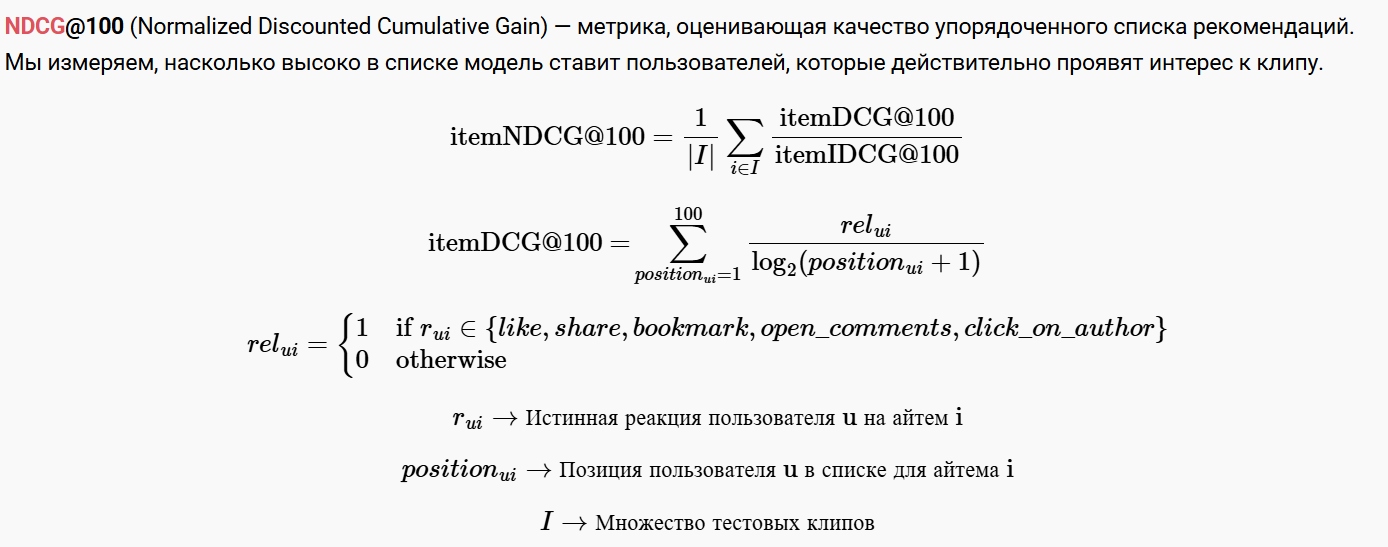

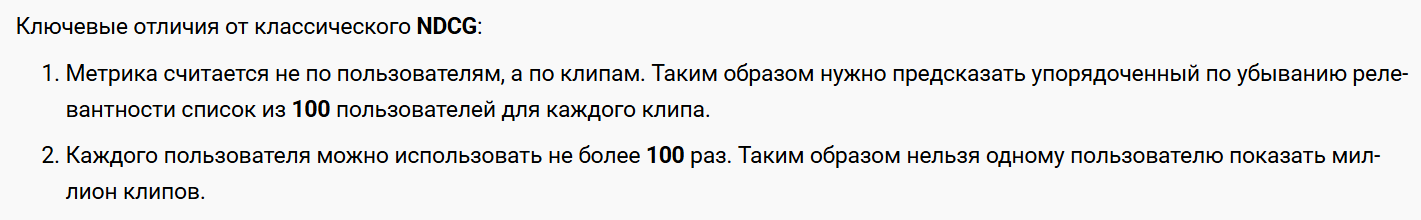

DSSM — двухбашенная нейросеть, которая проецирует пользователей и клипы в единое векторное пространство.

# Принцип работы:

User Tower: признаки пользователя → эмбеддинг размерности d

Item Tower: признаки клипа → эмбеддинг размерности d

Сходство: косинусное расстояние или скалярное произведение

Обучение: бинарная классификация (лайк/не лайк)

## Эксперименты и результаты

| № | EMBED_DIM | EPOCHS | Функция активации | Loss | NDCG@100 | Изменение NDCG |
|:-:|:---------:|:------:|:-----------------:|:----:|:--------:|:--------------:|
| 1 | 64 | 5 | ReLU | 0.3717 | 0.0014 | baseline |
| 2 | **128** | 5 | ReLU | 0.3720 | **0.0041** | **+192.9%** |
| 3 | 256 | 5 | ReLU | 0.3725 | 0.0012 | -14.3% |
| 4 | 512 | 5 | ReLU | 0.3722 | 0.0012 | -14.3% |
| 5 | 1024 | 5 | ReLU | 0.3737 | 0.0015 | +7.1% |

Выводы:

* Loss стабилен (~0.372) для всех размерностей

* Лучший NDCG при 128 (0.0041)

* Слишком высокая размерность (1024) ухудшает результат из-за переобучения

| № | EMBED_DIM | EPOCHS | Функция активации | Loss | NDCG@100 | Прирост NDCG |
|:-:|:---------:|:------:|:-----------------:|:----:|:--------:|:------------:|
| 1 | 256 | 3 | ReLU | 0.3734 | 0.0009 | baseline |
| 2 | 256 | 5 | ReLU | 0.3725 | 0.0012 | +33.3% |
| 3 | 256 | 7 | ReLU | 0.3710 | 0.0017 | +88.9% |
| 4 | **256** | **10** | ReLU | **0.3705** | **0.0020** | **+122.2%** |
| 5 | 256 | 15 | ReLU | 0.3684 | 0.0018 | +100.0% |

Выводы:

* Loss монотонно снижается с ростом эпох

* NDCG растет до 10 эпох (0.0020), затем падает

* Оптимум: 10 эпох

| № | EMBED_DIM | EPOCHS | Функция активации | Loss | NDCG@100 | Изменение относительно ReLU |
|:-:|:---------:|:------:|:-----------------:|:----:|:--------:|:---------------------------:|
| 1 | 256 | 5 | ReLU | 0.3725 | 0.0012 | baseline |
| 2 | 256 | 5 | Leaky ReLU | 0.3724 | 0.0023 | +91.7% |
| 3 | 256 | 5 | ELU | 0.3770 | 0.0017 | +41.7% |
| 4 | **256** | **5** | **Tanh** | **0.3768** | **0.0034** | **+183.3%** |
| 5 | 256 | 5 | Swish / SiLU | 0.3760 | 0.0011 | -8.3% |
| 6 | 256 | 5 | GELU | 0.3749 | 0.0025 | +108.3% |
| 7 | 256 | 5 | PReLU | 0.3733 | 0.0019 | +58.3% |

Выводы:

* Tanh дает лучший NDCG (0.0034) — на 183% лучше ReLU

* Leaky ReLU и GELU также показывают хорошие результаты

* ReLU — не оптимален для этой задачи

## Структура кода

Инициализация и настройки

In [ ]:
SUBSAMPLE = 'up0.001_ip0.001'  # подвыборка 0.1% данных
EMBED_DIM = 128                 # оптимальная размерность из экспериментов
EPOCHS = 10                     # оптимальное количество эпох
BATCH_SIZE = 1024               # размер батча для стабильности
LEARNING_RATE = 0.005           # скорость обучения

Загрузка данных

Загрузка данных

* Скачиваем метаданные пользователей и клипов

* Скачиваем взаимодействия по неделям (train: 0-9, validation: 25, test: 26)

* Собираем уникальные ID для фильтрации

Особенности:

Используем polars для быстрой обработки больших данных

## Feature Engineering
# Признаки пользователя:

1. age — возраст (нормализован)

2. train_interactions_rank — ранг активности

3. gender — one-hot кодирование

4. geo — one-hot кодирование

# Признаки клипа:

1. duration — длительность видео

2. train_interactions_rank — ранг популярности

3. author_id — идентификатор автора

# Дополнительные признаки (попытки улучшения):

1. coverage — процент видео автора, которые лайкнул пользователь

2. user_author_interaction — количество лайков пользователя автору

3. item_popularity — популярность клипа

## Генерация обучающей выборки

In [ ]:
class PairwiseDataset(Dataset):
    def __getitem__(self, idx):
        if idx % (neg_ratio + 1) == 0:
            return user, item, 1  # позитивный пример
        else:
            # выбираем случайного пользователя, который НЕ лайкал этот клип
            while neg_user in pos_by_item[item]:
                neg_user = random.choice(user_list)
            return neg_user, item, 0  # негативный пример

Негативные примеры выбираются из пользователей, которые не взаимодействовали с данным клипом — это заставляет модель учиться различать.

##  Архитектура DSSM

In [ ]:
class DSSM(nn.Module):
    def __init__(self, user_dim, item_dim, embed_dim=128):
        self.user_net = nn.Sequential(
            nn.Linear(user_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )
        self.item_net = nn.Sequential(
            nn.Linear(item_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def get_score(self, user_feat, item_feat):
        u = F.normalize(self.user_net(user_feat))
        i = F.normalize(self.item_net(item_feat))
        return (u * i).sum(dim=1)  # косинусное сходство

## Оптимизация и обучение


* Focal Loss — фокусируется на сложных примерах

* AdamW — оптимизатор с weight decay

* CosineAnnealingWarmRestarts — scheduler для выхода из локальных минимумов

* Gradient Clipping — предотвращает взрыв градиентов
* Поиск ближайших соседей (FAISS)

## Жадный алгоритм распределения

In [ ]:
for item_id in test_items:
    candidates = list(zip(neighbors[i], scores[i]))
    # Приоритет = score / log(2 + position) — учитывает позицию
    priority = score / np.log2(position + 2)
    # Штраф за уже использованных пользователей
    priority = priority / (1 + 0.1 * user_usage[user_id])

    # Выбираем лучших доступных пользователей
    for user in sorted(candidates, key=priority):
        if user_usage[user] < 100:
            selected.append(user)

NameError: name 'test_items' is not defined

## Идеи победителей соревнования
1. Некоторые реализовывали модель LGBM
2. Жадный алгоритм - очередь с приоритетом score/log(1+position)  
3. Использование библиотеки polars как более быстрой и удобной альтернативы pandas
4. Future Engineering - весомый вклад дает coverage (процент видео которые просматриввл или взаимодействовал юзер )
5. трансформер при использовании двухбашенной модели

## Что можно улучшить
* Увеличить подвыборку до 10-100%

* Добавить больше признаков:

1. Временные паттерны (время дня, день недели)

2. Текстовые признаки (название, описание)

3. Аудиовизуальные эмбеддинги

* Использовать GPU для обучения больших моделей

* Ensemble нескольких моделей

* Hard negative mining — выбирать сложные негативные примеры

### Оптимальные гиперпараметры

| № | Параметр | Оптимальное значение | Обоснование |
|:-:|:---------|:--------------------:|:------------|
| 1 | **EMBED_DIM** | **128** | Максимальный NDCG (0.0041), на 193% лучше baseline |
| 2 | **EPOCHS** | **10** | Оптимум по NDCG (0.0020), при 15 эпохах переобучение |
| 3 | **Функция активации** | **Tanh** | Лучший NDCG (0.0034), на 183% лучше ReLU |
| 4 | **BATCH_SIZE** | **1024** | Баланс скорости обучения и качества |
| 5 | **LEARNING_RATE** | **0.005** | Обеспечивает стабильную сходимость |
| 6 | **NEG_RATIO** | **5** | Классическое соотношение позитив/негатив |
| 7 | **TOP_K_CANDIDATES** | **500** | Баланс между качеством поиска и скоростью |

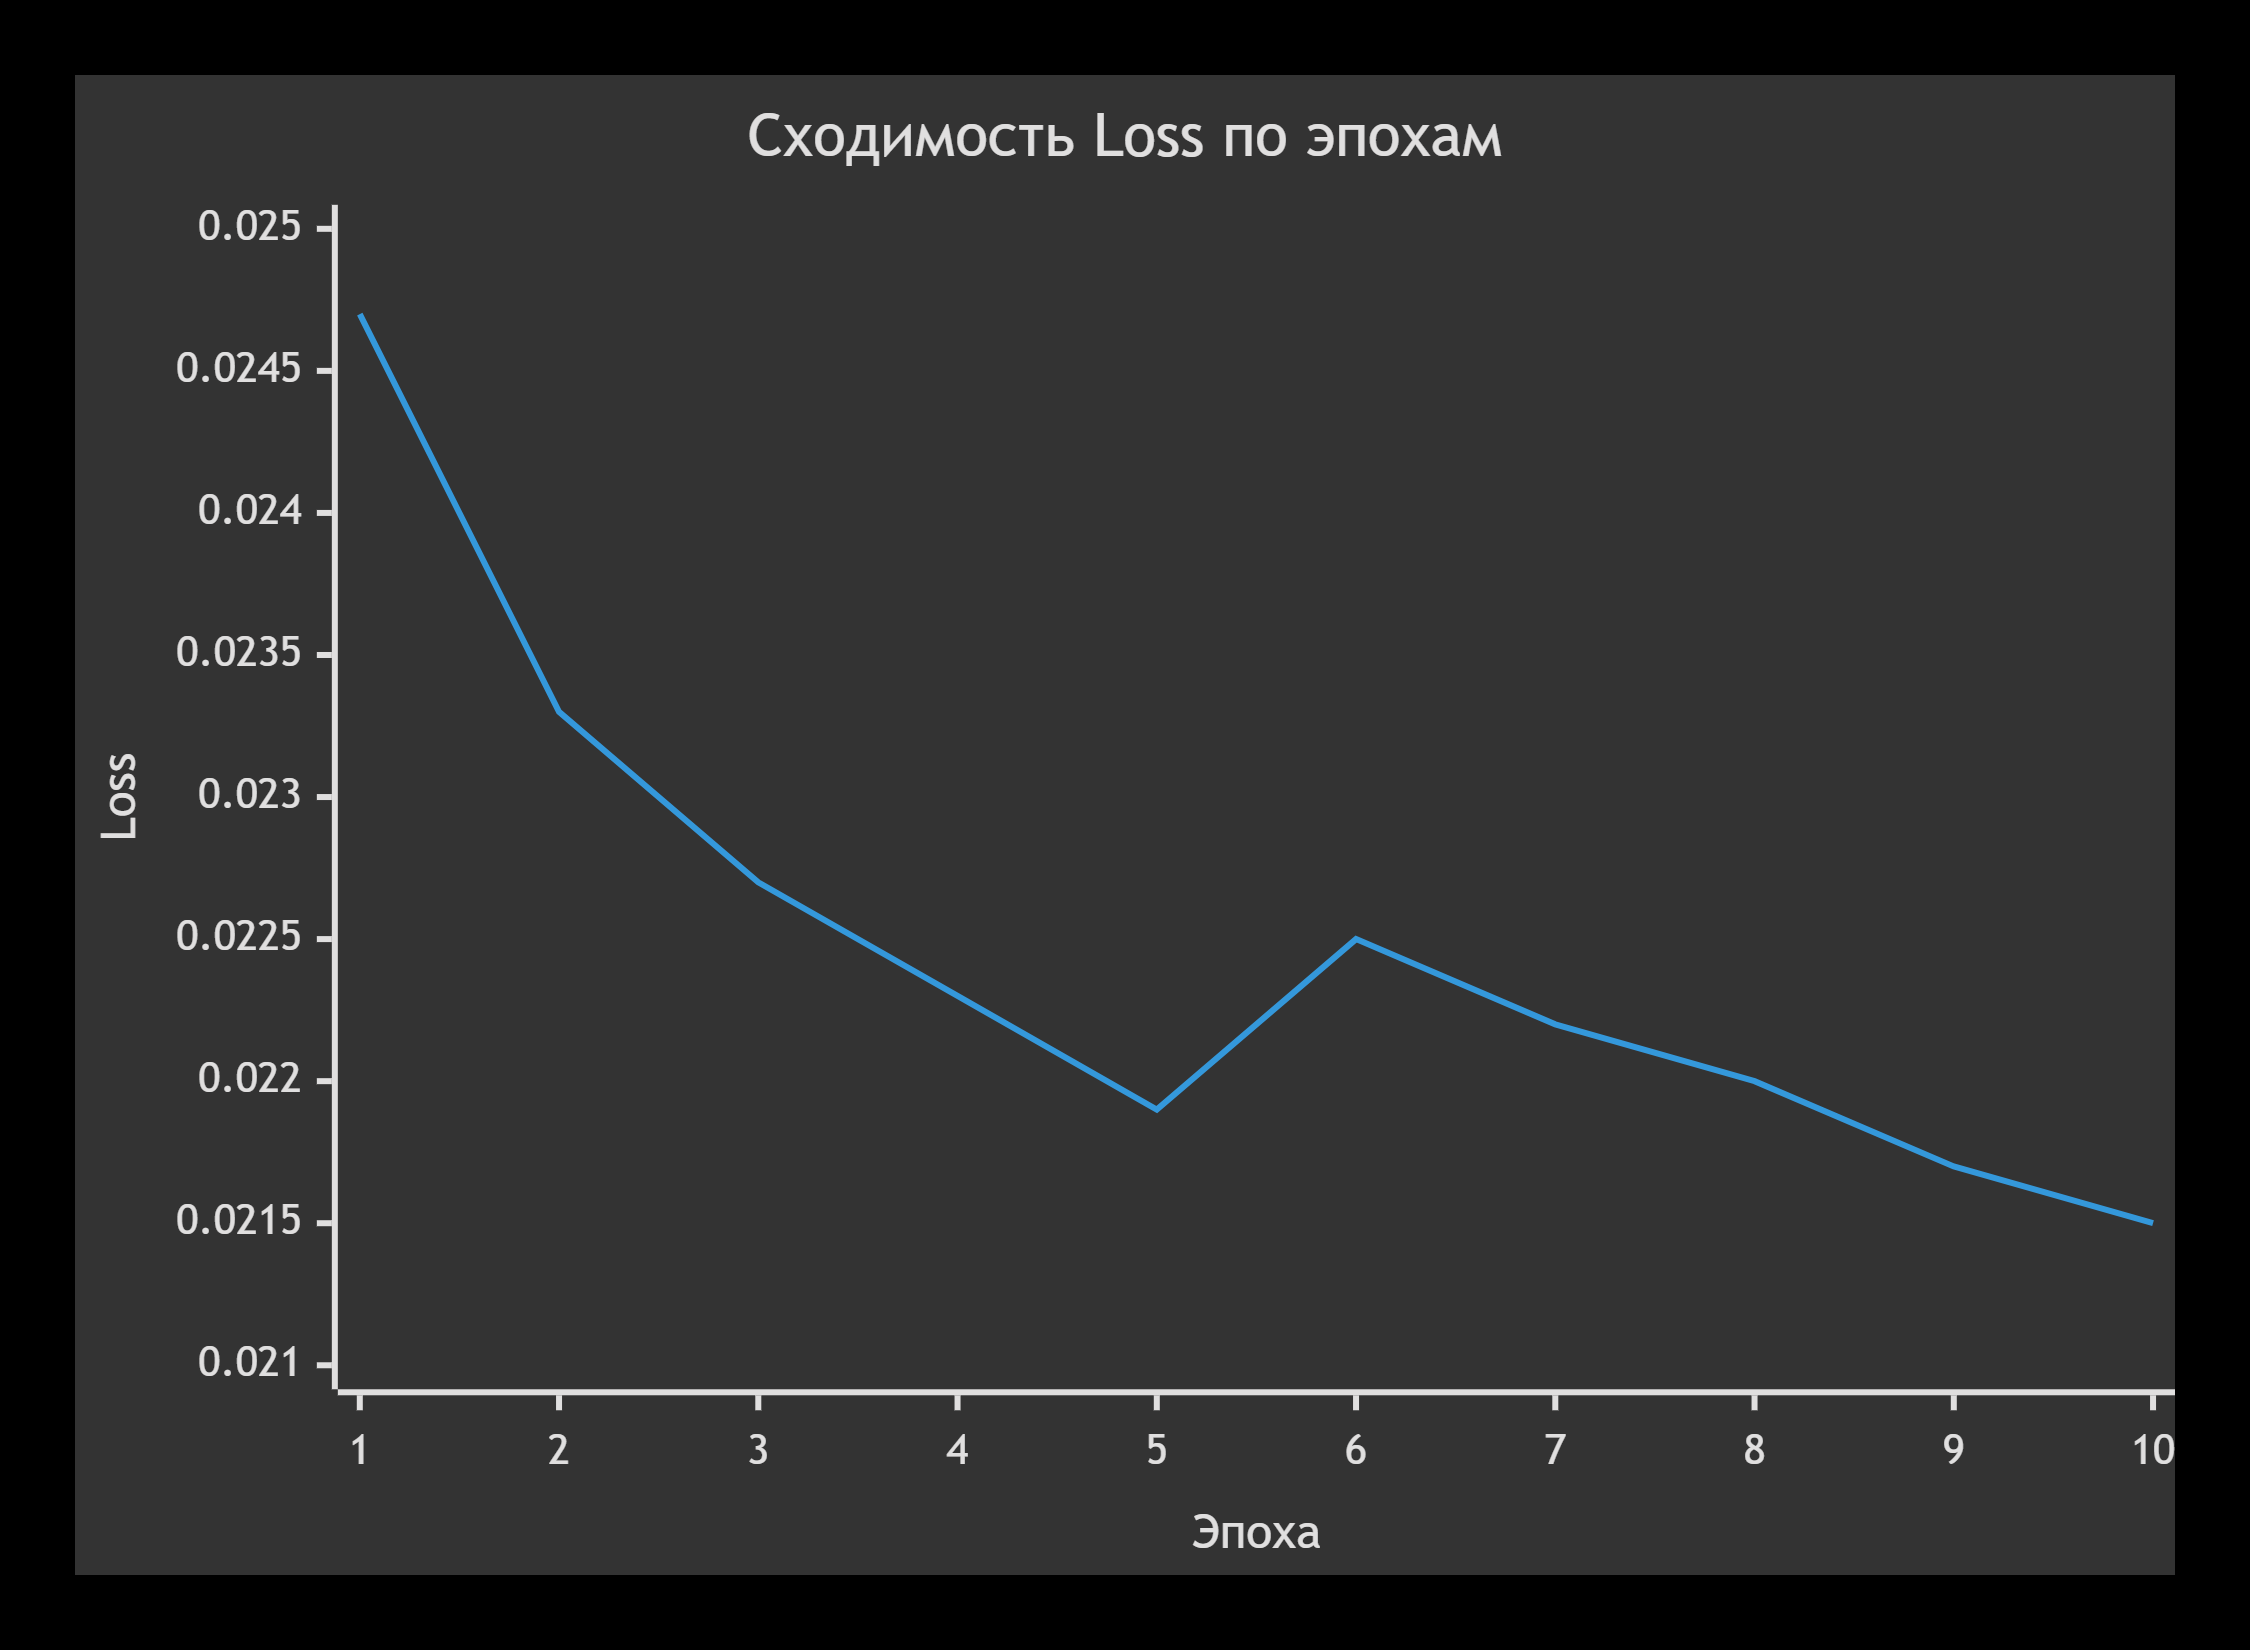

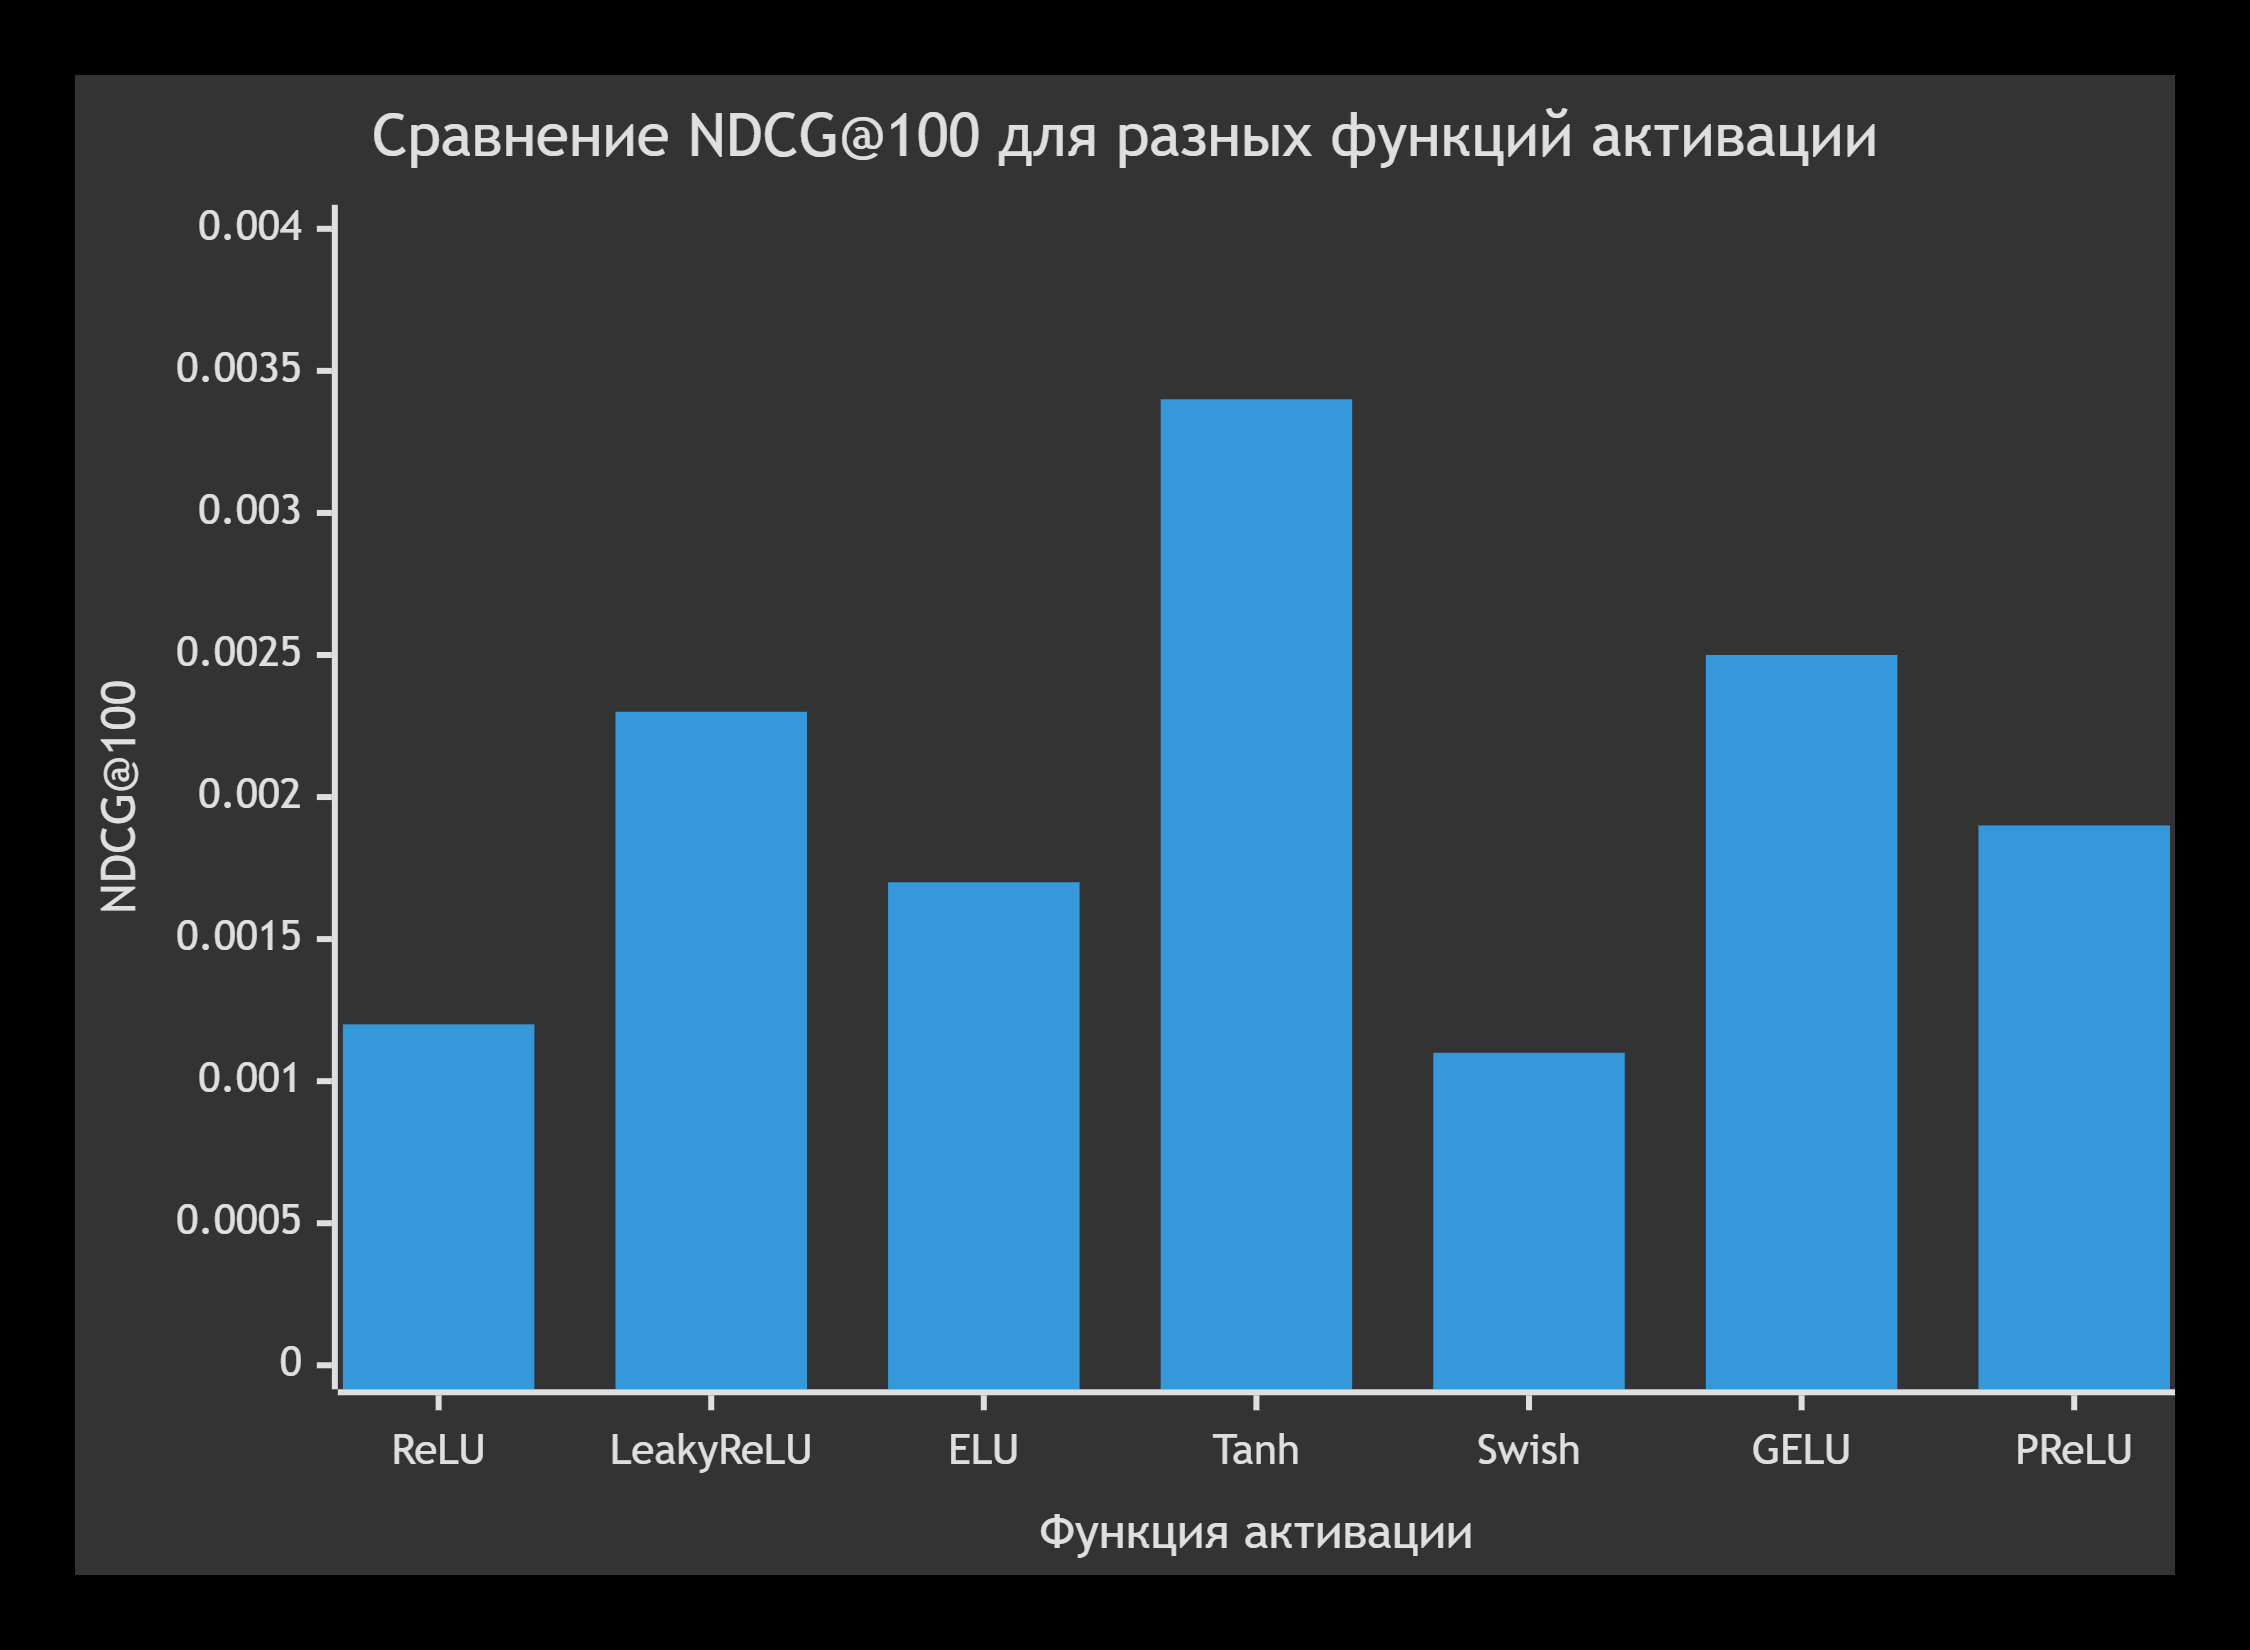